   Всего найдено конфигураций: 8757
   Найдено уникальных плотностей: 7 (0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90)
   Для равномерного деления берем по 931 симуляций от каждой плотности.
  - Train симуляций: 4564
  - Val симуляций:   973
  - Test симуляций:  980

Рекомендуемые параметры на основе общего Grid Search:
  - Оптимальный n_estimators = 500
  - Оптимальный max_depth = 20

 Метрики на валидации (VAL)
R² h: 0.9018 | MAE h: 0.0318
R² p: 0.9844 | MAE p: 0.3201

 Метрики на тесте (TEST)
R² h: 0.9094 | MAE h: 0.0314
R² p: 0.9842 | MAE p: 0.3201

Важность признаков финальной модели:
diffusion_coeff       0.636761
psi_6                 0.090408
density               0.077509
voronoi_peak_ratio    0.048420
psi_5                 0.047152
num_layers            0.047115
psi_4                 0.018888
snake_length_avg      0.015743
psi_3                 0.015381
triplet_raw_count     0.001914
voronoi_peaks         0.000298
is_phase_separated    0.000206
dominant_k            0.000178
is_l

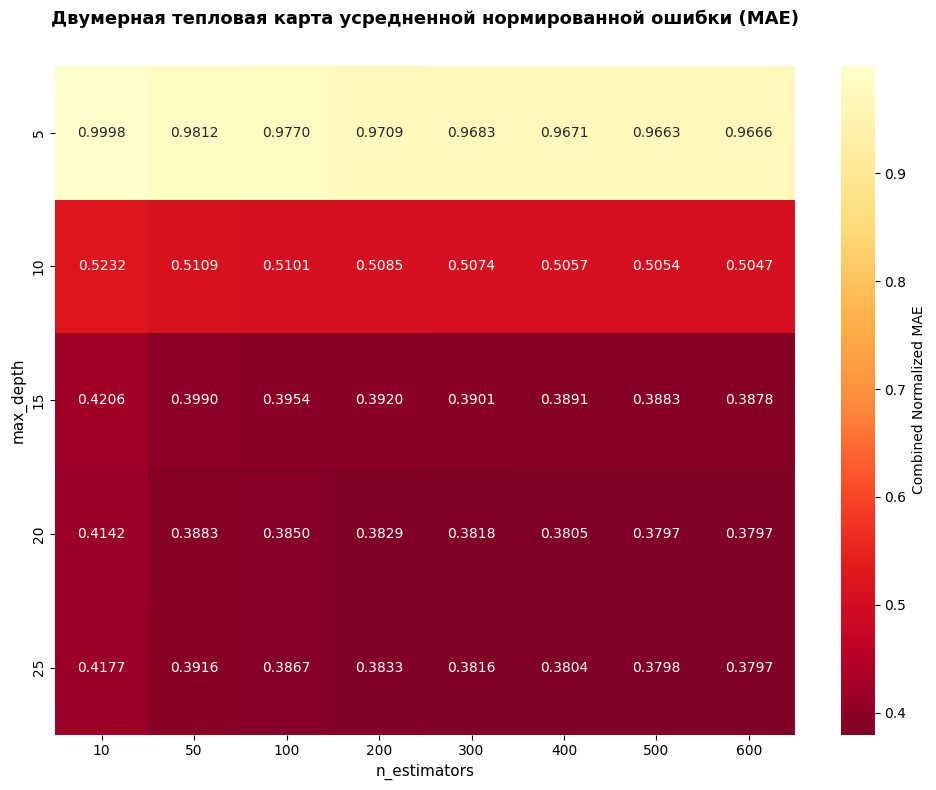

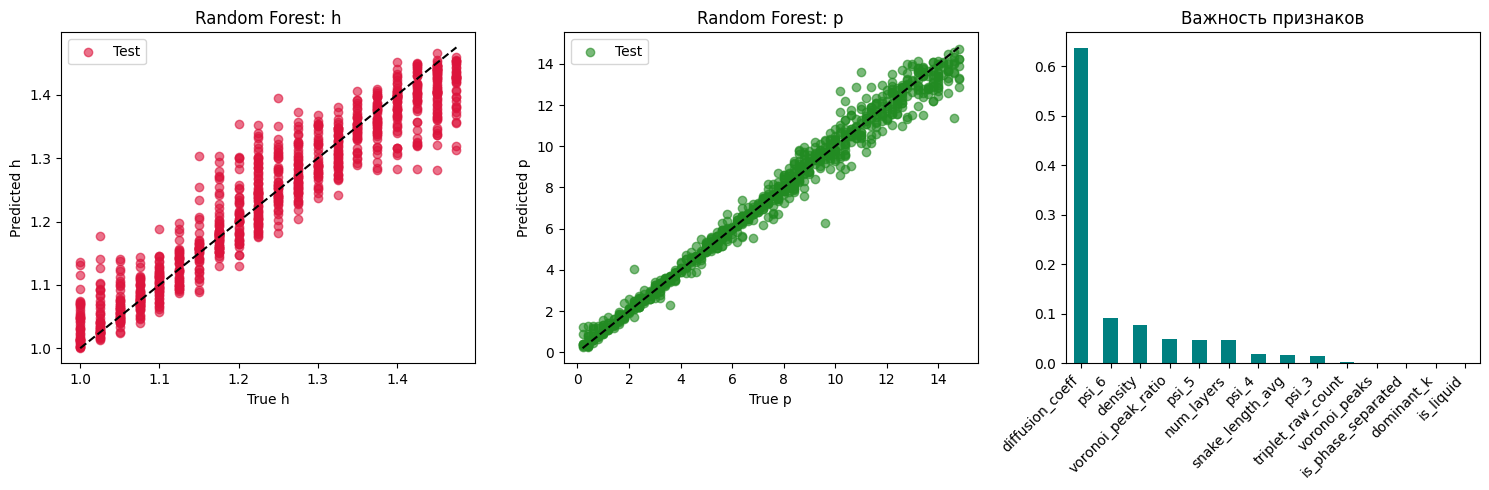

In [15]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, field
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. НАСТРОЙКИ ПУТЕЙ И СЕТКИ СИМУЛЯЦИИ
SIM_DIR = r"C:\Users\user\Downloads\sim_txt_all"  

N_FILES = None  

RANDOM_SEED = 42
TEMP = 1.0

# Сетки значений h и mu (p) для поиска файлов
h_values = np.arange(1.0, 1.475, 0.025)
mu_values = np.arange(1.0, 10.6, 0.2)

# Порог диффузии
SIM_MSD_THRESHOLD = 0.05

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# 2. СТРУКТУРА ДАННЫХ ИЗ PHASE_MAP
@dataclass
class SimulationPoint:
    h: float
    mu: float
    rho: float
    temp: float

    # Физические свойства
    num_layers: int = 0
    diffusion_coeff: float = 0.0
    mobility_phase: str = "Unknown"
    psi_values: dict = field(default_factory=dict)
    dominant_k: int = 0

    # Вороной / Флуктуации плотности
    voronoi_peaks: int = 0
    voronoi_peak_pos: list = field(default_factory=list)
    is_phase_separated: bool = False

    # Змейки и триплеты
    triplet_raw_count: int = 0
    snake_length_avg: float = 0.0

# 3. ФУНКЦИИ-АНАЛИЗАТОРЫ ИЗ PHASE_MAP
def parse_global_filename(filepath):
    base = os.path.basename(filepath)
    base = os.path.splitext(base)[0]
    parts = base.split("_")
    try:
        rho = float(parts[1])
        h = float(parts[2])
        temp = float(parts[3])
        mu = float(parts[4])
        return rho, h, temp, mu
    except Exception:
        return None, None, None, None


def get_all_sim_points(data_dir):
    points_dict = {}
    pattern = os.path.join(data_dir, "Sigma2t_*.txt")
    files = glob.glob(pattern)
    for f in files:
        rho, h, temp, mu = parse_global_filename(f)
        if rho is not None:
            points_dict[(rho, h, temp, mu)] = SimulationPoint(h=h, mu=mu, rho=rho, temp=temp)
    return points_dict


def analyze_z_coord(points_dict, data_dir):
    for pt in points_dict.values():
        filepath = os.path.join(data_dir, f"Z_coord_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
        try:
            data = np.loadtxt(filepath)
            if data.size > 0 and len(data.shape) == 2:
                counts = data[:, 1]
                if max(counts) > 0: counts = counts / max(counts)
                peaks, _ = find_peaks(np.concatenate(([0], counts, [0])), prominence=0.02)
                pt.num_layers = len(peaks)
        except Exception:
            pt.num_layers = 0


def analyze_msd(points_dict, data_dir, threshold):
    for pt in points_dict.values():
        filepath = os.path.join(data_dir, f"Sigma2t_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
        try:
            msd = np.loadtxt(filepath)
            if msd.size >= 10:
                time = np.arange(len(msd))
                half_idx = len(msd[:-1]) // 2
                k, b = np.polyfit(time[half_idx:], msd[half_idx:], 1)
                pt.diffusion_coeff = k / 4.0
                pt.mobility_phase = 'Liquid' if pt.diffusion_coeff >= threshold else 'Crystal'
        except Exception:
            pt.diffusion_coeff = 0.0
            pt.mobility_phase = 'Unknown'


def analyze_orientational_order(points_dict, data_dir, threshold=0.4):
    for pt in points_dict.values():
        for k in [3, 4, 5, 6]:
            filepath = os.path.join(data_dir, f"AvPsi{k}_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
            try:
                data = np.loadtxt(filepath)
                val = float(np.mean(data)) if data.size > 1 else float(data)
                pt.psi_values[k] = val
            except Exception:
                pt.psi_values[k] = 0.0

        if not pt.psi_values: continue
        max_k = max(pt.psi_values, key=pt.psi_values.get)
        pt.dominant_k = max_k if pt.psi_values[max_k] >= threshold else 0


def analyze_voronoi_fluctuations(points_dict, data_dir, min_prominence=0.05, min_distance_ratio=2.0):
    for pt in points_dict.values():
        filepath = os.path.join(data_dir, f"S_vor(RDF)__{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
        try:
            data = np.loadtxt(filepath)
            x = data[:, 0] if data.ndim == 2 else np.arange(len(data))
            y = data[:, 1] if data.ndim == 2 else data
            if max(y) > 0: y = y / max(y)

            peaks, _ = find_peaks(y, prominence=min_prominence)
            pt.voronoi_peaks = len(peaks)
            pt.voronoi_peak_pos = x[peaks].tolist()
            pt.is_phase_separated = False

            if len(pt.voronoi_peak_pos) >= 2:
                small_p, big_p = min(pt.voronoi_peak_pos), max(pt.voronoi_peak_pos)
                if small_p > 0 and (big_p / small_p) >= min_distance_ratio:
                    pt.is_phase_separated = True
        except Exception:
            pt.is_phase_separated = False


def analyze_triplets(points_dict, data_dir):
    for pt in points_dict.values():
        filepath = os.path.join(data_dir, f"Triplets_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
        if os.path.exists(filepath):
            try:
                data = np.atleast_1d(np.loadtxt(filepath))
                if data.size == 0 or (len(data) == 1 and data[0] == 0):
                    pt.triplet_raw_count = 0
                else:
                    pt.triplet_raw_count = len(data)
            except Exception:
                pt.triplet_raw_count = 0


def analyze_snake_length(points_dict, data_dir):
    for pt in points_dict.values():
        filepath = os.path.join(data_dir, f"Av_Length_{pt.rho}_{pt.h}_{pt.temp}_{pt.mu}.txt")
        try:
            pt.snake_length_avg = float(np.loadtxt(filepath))
        except Exception:
            pt.snake_length_avg = 0.0


# 4. СБОР ДАТАСЕТА 
all_sim_points = get_all_sim_points(SIM_DIR)

if not all_sim_points:
    raise ValueError(f"Не найдено файлов симуляций в папке: {SIM_DIR}")

print(f"   Всего найдено конфигураций: {len(all_sim_points)}")

keys = list(all_sim_points.keys())

# Группируем абсолютно все конфигурации по плотностям
all_density_groups = {}
for k in keys:
    density_val = f"{k[0]:.2f}"
    if density_val not in all_density_groups:
        all_density_groups[density_val] = []
    all_density_groups[density_val].append(k)

num_densities = len(all_density_groups)
print(f"   Найдено уникальных плотностей: {num_densities} ({', '.join(all_density_groups.keys())})")

# Определяем, сколько файлов брать от каждой плотности для баланса
if N_FILES is not None:
    files_per_density = N_FILES // num_densities
    min_available = min(len(g) for g in all_density_groups.values())
    if files_per_density > min_available:
        print(f"   Самая малочисленная плотность имеет только {min_available} файлов.")
        print(f"   Размер выборки уменьшен до максимального равномерного: {min_available} на плотность.")
        files_per_density = min_available
else:
    # Если N_FILES=None, выравниваем по самой малочисленной плотности, чтобы деление было строго равномерным
    files_per_density = min(len(g) for g in all_density_groups.values())

print(f"   Для равномерного деления берем по {files_per_density} симуляций от каждой плотности.")

# Распределяем файлы по выборкам 70/15/15 строго внутри каждой плотности
train_keys = []
val_keys = []
test_keys = []

for density_val, group_keys in all_density_groups.items():
    # Перемешиваем файлы внутри плотности для случайности
    random.shuffle(group_keys)
    
    # Отбираем нужное количество файлов для этой плотности
    selected_group = group_keys[:files_per_density]
    n_samples = len(selected_group)
    
    # Рассчитываем точные границы для пропорции 70% / 15% / 15%
    n_train = int(round(n_samples * 0.7))
    n_remaining = n_samples - n_train
    n_val = n_remaining // 2
    n_test = n_remaining - n_val
    
    # Распределяем
    train_keys.extend(selected_group[:n_train])
    val_keys.extend(selected_group[n_train:n_train + n_val])
    test_keys.extend(selected_group[n_train + n_val:])

# Сводный набор выбранных конфигураций
selected_keys = train_keys + val_keys + test_keys

print(f"  - Train симуляций: {len(train_keys)}")
print(f"  - Val симуляций:   {len(val_keys)}")
print(f"  - Test симуляций:  {len(test_keys)}")

train_keys_set = set(train_keys)
val_keys_set = set(val_keys)

# Создаем подсловарь только для выбранных точек
selected_sim_dict = {k: all_sim_points[k] for k in selected_keys}

analyze_z_coord(selected_sim_dict, SIM_DIR)
analyze_msd(selected_sim_dict, SIM_DIR, SIM_MSD_THRESHOLD)
analyze_orientational_order(selected_sim_dict, SIM_DIR)
analyze_voronoi_fluctuations(selected_sim_dict, SIM_DIR)
analyze_triplets(selected_sim_dict, SIM_DIR)
analyze_snake_length(selected_sim_dict, SIM_DIR)

# Преобразуем извлеченные объекты в DataFrame
data_rows = []
for key, pt in selected_sim_dict.items():
    peak_ratio = 1.0
    if len(pt.voronoi_peak_pos) >= 2 and min(pt.voronoi_peak_pos) > 0:
        peak_ratio = max(pt.voronoi_peak_pos) / min(pt.voronoi_peak_pos)

    # Определяем маркер выборки
    if key in train_keys_set:
        split_name = "train"
    elif key in val_keys_set:
        split_name = "val"
    else:
        split_name = "test"

    data_rows.append({
        "density": pt.rho,
        "h": pt.h,
        "p": pt.mu,  # mu — это dipole moment (p)
        
        # Глобальные признаки
        "num_layers": pt.num_layers,
        "diffusion_coeff": pt.diffusion_coeff,
        "is_liquid": 1.0 if pt.mobility_phase == 'Liquid' else 0.0,
        "psi_3": pt.psi_values.get(3, 0.0),
        "psi_4": pt.psi_values.get(4, 0.0),
        "psi_5": pt.psi_values.get(5, 0.0),
        "psi_6": pt.psi_values.get(6, 0.0),
        "dominant_k": pt.dominant_k,
        "voronoi_peaks": pt.voronoi_peaks,
        "is_phase_separated": 1.0 if pt.is_phase_separated else 0.0,
        "voronoi_peak_ratio": peak_ratio,
        "triplet_raw_count": pt.triplet_raw_count,
        "snake_length_avg": pt.snake_length_avg,
        "split": split_name
    })

df = pd.DataFrame(data_rows)

train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "val"]
test_df = df[df["split"] == "test"]

target_cols = ["h", "p"]
exclude_cols = ["split"] + target_cols

X_train = train_df.drop(columns=exclude_cols)
y_train = train_df[target_cols]

X_val = val_df.drop(columns=exclude_cols)
y_val = val_df[target_cols]

X_test = test_df.drop(columns=exclude_cols)
y_test = test_df[target_cols]


# 5. ДВУМЕРНЫЙ ПОДБОР ГИПЕРПАРАМЕТРОВ (GRID SEARCH)

# Опеределяем сетку параметров
n_estimators_grid = [10, 50, 100, 200, 300, 400, 500, 600]
max_depth_grid = [5, 10, 15, 20, 25]

# Инициализируем пустые матрицы ошибок
mae_h_matrix = np.zeros((len(max_depth_grid), len(n_estimators_grid)))
mae_p_matrix = np.zeros((len(max_depth_grid), len(n_estimators_grid)))

for i, depth in enumerate(max_depth_grid):
    for j, n_est in enumerate(n_estimators_grid):
        model_temp = RandomForestRegressor(
            n_estimators=n_est,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        )
        model_temp.fit(X_train, y_train)
        preds_temp = model_temp.predict(X_val)
        
        # Записываем ошибки в соответствующие ячейки матрицы
        mae_h_matrix[i, j] = mean_absolute_error(y_val["h"], preds_temp[:, 0])
        mae_p_matrix[i, j] = mean_absolute_error(y_val["p"], preds_temp[:, 1])

# Нормирование матриц ошибок на их максимум
norm_h = mae_h_matrix / mae_h_matrix.max()
norm_p = mae_p_matrix / mae_p_matrix.max()

combined_score = (norm_h + norm_p) / 2.0

# Находим плоский индекс минимума и переводим его в двумерные координаты (i, j)
best_i, best_j = np.unravel_index(np.argmin(combined_score), combined_score.shape)

best_n_estimators = n_estimators_grid[best_j]
best_max_depth = max_depth_grid[best_i]

print(f"\nРекомендуемые параметры на основе общего Grid Search:")
print(f"  - Оптимальный n_estimators = {best_n_estimators}")
print(f"  - Оптимальный max_depth = {best_max_depth}")

# 6. ОБУЧЕНИЕ И ОЦЕНКА ФИНАЛЬНОЙ МОДЕЛИ
final_model = RandomForestRegressor(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train, y_train)

# Получение предсказаний
preds_val = final_model.predict(X_val)
preds_test = final_model.predict(X_test)

# Расчет финальных метрик
r2_h_val = r2_score(y_val["h"], preds_val[:, 0])
r2_p_val = r2_score(y_val["p"], preds_val[:, 1])
mae_h_val = mean_absolute_error(y_val["h"], preds_val[:, 0])
mae_p_val = mean_absolute_error(y_val["p"], preds_val[:, 1])

r2_h_test = r2_score(y_test["h"], preds_test[:, 0])
r2_p_test = r2_score(y_test["p"], preds_test[:, 1])
mae_h_test = mean_absolute_error(y_test["h"], preds_test[:, 0])
mae_p_test = mean_absolute_error(y_test["p"], preds_test[:, 1])

print("\n Метрики на валидации (VAL)")
print(f"R² h: {r2_h_val:.4f} | MAE h: {mae_h_val:.4f}")
print(f"R² p: {r2_p_val:.4f} | MAE p: {mae_p_val:.4f}")

print("\n Метрики на тесте (TEST)")
print(f"R² h: {r2_h_test:.4f} | MAE h: {mae_h_test:.4f}")
print(f"R² p: {r2_p_test:.4f} | MAE p: {mae_p_test:.4f}")

# Важность признаков финальной модели
importance = pd.Series(final_model.feature_importances_, index=X_train.columns)
print("\nВажность признаков финальной модели:")
print(importance.sort_values(ascending=False))


# 7.1. Построение одной тепловой карты комбинированной ошибки
plt.figure(figsize=(10, 8))
sns.heatmap(
    combined_score,
    annot=True,
    fmt=".4f",
    xticklabels=n_estimators_grid,
    yticklabels=max_depth_grid,
    cmap="YlOrRd_r",  
    cbar_kws={'label': 'Combined Normalized MAE'}
)
plt.title("Двумерная тепловая карта усредненной нормированной ошибки (MAE)\n", 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel("n_estimators", fontsize=11)
plt.ylabel("max_depth", fontsize=11)
plt.tight_layout()
plt.show()

# 7.2. График True vs Predicted и важности признаков
plt.figure(figsize=(15, 5))

# График для h
plt.subplot(1, 3, 1)
plt.scatter(y_test["h"], preds_test[:, 0], color="crimson", alpha=0.6, marker="o", label="Test")
min_v = min(y_test["h"].min(), preds_test[:, 0].min(), y_val["h"].min())
max_v = max(y_test["h"].max(), preds_test[:, 0].max(), y_val["h"].max())
plt.plot([min_v, max_v], [min_v, max_v], "k--")
plt.title("Random Forest: h")
plt.xlabel("True h")
plt.ylabel("Predicted h")
plt.legend()

# График для p (mu)
plt.subplot(1, 3, 2)
plt.scatter(y_test["p"], preds_test[:, 1], color="forestgreen", alpha=0.6, marker="o", label="Test")
min_v = min(y_test["p"].min(), preds_test[:, 1].min(), y_val["p"].min())
max_v = max(y_test["p"].max(), preds_test[:, 1].max(), y_val["p"].max())
plt.plot([min_v, max_v], [min_v, max_v], "k--")
plt.title("Random Forest: p")
plt.xlabel("True p")
plt.ylabel("Predicted p")
plt.legend()

# Важность признаков
plt.subplot(1, 3, 3)
importance.sort_values(ascending=False).plot.bar(color="teal")
plt.title("Важность признаков")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()